In [27]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
import plotly.graph_objects as go
import nbformat
import os

# random seed for reproducibility
np.random.seed(642)

In [28]:
# using an API call to load the dataset from the Ontario Data Catalogue (for reproducibility and flexibility)
## replace the url value below with the endpoint of your dataset of choice
# API stuff was redundant, just link to the file will do
# here is the current source:
# https://data.ontario.ca/dataset/ops-workforce-demographics/resource/73a52425-92c0-440e-bad5-badd42edfbe9

import urllib.request
url = 'https://data.ontario.ca/dataset/7b3152eb-879a-4545-b5f9-fb52dc42cf65/resource/73a52425-92c0-440e-bad5-badd42edfbe9/download/ops_workforce_demographic_dataset_-_2015_to_2025_english.csv'  


In [ ]:
# save the data file via the link to "/Data/" use in Power BI later. 
# Sadly, all API calls and web connectors were blocked for me for Power BI from this resource.

save_dir = "Data/"
os.makedirs(save_dir, exist_ok=True)

# Local file path
file_path = os.path.join(save_dir, "ops_workforce_demographic_dataset_2015_to_2025_english.csv")

# Download and save
response = requests.get(url)
response.raise_for_status()  # Raise an error if download failed

with open(file_path, "wb") as f:
    f.write(response.content)

print(f"✅ File saved to: {file_path}")




✅ File saved to: Data/ops_workforce_demographic_dataset_2015_to_2025_english.csv


In [30]:
fileobj = urllib.request.urlopen(url)
print(fileobj.read())
# show data summary
data_opswf = pd.read_csv(url)
print(data_opswf.info())

b'Date,FTE Allocation, FTE Actuals,Variance,Student FTEs,Intern FTEs,Seasonal FTEs,Pending LTIP and Salary Continuance FTEs,Total Staff Strength FTEs (basis for remaining columns) ,Regular FTEs,Non-Regular FTEs,OPSEU FTEs,AMAPCEO FTEs,OPPA FTEs,ALOC/OCAA FTEs,AOPDPS FTEs,PEGO FTEs,PSAT FTEs,Total OPS Unionized FTEs,MCP FTEs,SMG/ITX FTEs,Excluded FTEs,OPPCOA FTEs,OTHER Non-Unionized FTEs,Total OPS Non-Unionized FTEs,FTEs in Central Region,FTEs in West Region,FTEs in East Region,FTEs in North Region,Total Female FTEs,Total Male FTEs,Total Manager FTEs,Female Manager FTEs,Male Manager FTEs,Average Age (Regular),Average Age (Non-regular),Average Age (All),Average Tenure Regular (Years),Average Tenure Non-Regular (Years),Average Tenure All (Years),Average Sick Credit Days Taken Last Complete Calendar Year,Average Staff with <6 Sick Days Taken (Last Complete Year),Average Staff with >6 Sick Days Taken (Last Complete Year),Average Salary ($),Median Salary ($),Female Average Annual Salary,Male

In [31]:
data_opswf.head()

,Date,FTE Allocation,FTE Actuals,Variance,Student FTEs,Intern FTEs,Seasonal FTEs,Pending LTIP and Salary Continuance FTEs,Total Staff Strength FTEs (basis for remaining columns),Regular FTEs,...,"Females Earning $100,000 - $149,999","Males Earning $100,000 - $149,999","Females Earning $150,000 - $199,999","Males Earning $150,000 - $199,999","Females Earning $200,000 - $249,999","Males Earning $200,000 - $249,999","Females Earning $250,000 - $299,999","Males Earning $250,000 - $299,999","Females Earning $300,000 and Over","Males Earning $300,000 and Over"
0,2015-03-31,65167.5,62932.8,-2234.7,511.1,296.5,814.9,307.4,64862.7,55308.9,...,2675.0,4425.9,759.3,728.9,12.9,41.0,106.9,188.5,10.4,23.0
1,2016-03-31,65592.5,63139.1,-2453.4,484.1,286.3,866.7,274.5,65050.7,55217.8,...,3003.8,4643.5,828.5,743.8,41.9,72.0,105.2,181.4,9.0,33.0
2,2017-03-31,66362.5,63881.8,-2480.7,555.0,307.0,852.9,208.0,65804.8,54421.6,...,4642.5,6887.8,806.1,771.0,131.9,161.0,122.5,185.0,10.4,33.7
3,2018-03-31,67161.8,66569.0,-592.8,653.6,371.0,929.0,245.5,68768.1,56070.0,...,5840.9,8501.2,1033.3,964.2,154.6,182.9,148.8,177.0,18.4,48.3
4,2019-03-31,68084.2,65568.3,-2515.9,623.2,395.0,912.0,247.8,67751.3,55860.2,...,6228.2,8676.6,1038.0,905.7,143.0,172.0,23.2,25.0,135.2,198.7


In [32]:
data_opswf

,Date,FTE Allocation,FTE Actuals,Variance,Student FTEs,Intern FTEs,Seasonal FTEs,Pending LTIP and Salary Continuance FTEs,Total Staff Strength FTEs (basis for remaining columns),Regular FTEs,...,"Females Earning $100,000 - $149,999","Males Earning $100,000 - $149,999","Females Earning $150,000 - $199,999","Males Earning $150,000 - $199,999","Females Earning $200,000 - $249,999","Males Earning $200,000 - $249,999","Females Earning $250,000 - $299,999","Males Earning $250,000 - $299,999","Females Earning $300,000 and Over","Males Earning $300,000 and Over"
0,2015-03-31,65167.5,62932.8,-2234.7,511.10,296.5,814.9,307.4,64862.7,55308.9,...,2675.0,4425.9,759.3,728.9,12.9,41.0,106.9,188.5,10.4,23.0
1,2016-03-31,65592.5,63139.1,-2453.4,484.10,286.3,866.7,274.5,65050.7,55217.8,...,3003.8,4643.5,828.5,743.8,41.9,72.0,105.2,181.4,9.0,33.0
2,2017-03-31,66362.5,63881.8,-2480.7,555.00,307.0,852.9,208.0,65804.8,54421.6,...,4642.5,6887.8,806.1,771.0,131.9,161.0,122.5,185.0,10.4,33.7
3,2018-03-31,67161.8,66569.0,-592.8,653.60,371.0,929.0,245.5,68768.1,56070.0,...,5840.9,8501.2,1033.3,964.2,154.6,182.9,148.8,177.0,18.4,48.3
4,2019-03-31,68084.2,65568.3,-2515.9,623.20,395.0,912.0,247.8,67751.3,55860.2,...,6228.2,8676.6,1038.0,905.7,143.0,172.0,23.2,25.0,135.2,198.7
5,2020-03-31,67419.7,62922.1,-4497.6,641.50,289.5,898.0,1395.9,66150.0,54320.9,...,6731.6,9066.2,507.3,551.4,631.6,547.7,30.8,24.0,139.1,183.8
6,2021-03-31,67545.7,63698.4,-3847.2,543.90,256.6,877.9,398.2,65830.0,54295.4,...,7169.7,9275.1,521.8,538.0,651.9,570.2,20.0,18.0,158.3,186.8
7,2022-03-31,66454.5,65857.3,-597.2,617.70,304.7,855.3,294.7,68000.7,54787.0,...,8077.7,9766.0,739.4,705.3,656.6,567.4,31.9,31.0,159.7,175.9
8,2023-03-31,67018.0,67423.0,425.0,797.60,413.8,933.6,272.8,69933.9,55624.0,...,8767.2,10521.5,734.3,675.3,678.0,573.8,37.6,33.0,159.0,177.4
9,2024-03-31,67771.4,69527.3,1755.9,972.70,408.0,1078.8,228.0,72301.7,57154.2,...,9303.4,10963.4,834.3,750.1,692.9,563.5,33.6,29.6,171.0,178.4


In [33]:
# identify % of 'Females Earning  $100,000 - $149,999' and 'Males Earning  $100,000 - $149,999' vs 'Total Female FTEs' and 'Total Male FTEs'
data_opswf['% of OPS Females Earning  $100,000 - $149,999'] = data_opswf['Females Earning  $100,000 - $149,999'] / data_opswf['Total Female FTEs'] * 100
data_opswf['% of OPS Males Earning  $100,000 - $149,999'] = data_opswf['Males Earning  $100,000 - $149,999'] / data_opswf['Total Male FTEs'] * 100
# add new columns to dataframe
data_opswf



,Date,FTE Allocation,FTE Actuals,Variance,Student FTEs,Intern FTEs,Seasonal FTEs,Pending LTIP and Salary Continuance FTEs,Total Staff Strength FTEs (basis for remaining columns),Regular FTEs,...,"Females Earning $150,000 - $199,999","Males Earning $150,000 - $199,999","Females Earning $200,000 - $249,999","Males Earning $200,000 - $249,999","Females Earning $250,000 - $299,999","Males Earning $250,000 - $299,999","Females Earning $300,000 and Over","Males Earning $300,000 and Over","% of OPS Females Earning $100,000 - $149,999","% of OPS Males Earning $100,000 - $149,999"
0,2015-03-31,65167.5,62932.8,-2234.7,511.10,296.5,814.9,307.4,64862.7,55308.9,...,759.3,728.9,12.9,41.0,106.9,188.5,10.4,23.0,7.444866,15.465766
1,2016-03-31,65592.5,63139.1,-2453.4,484.10,286.3,866.7,274.5,65050.7,55217.8,...,828.5,743.8,41.9,72.0,105.2,181.4,9.0,33.0,8.329867,16.212036
2,2017-03-31,66362.5,63881.8,-2480.7,555.00,307.0,852.9,208.0,65804.8,54421.6,...,806.1,771.0,131.9,161.0,122.5,185.0,10.4,33.7,12.731107,23.873530
3,2018-03-31,67161.8,66569.0,-592.8,653.60,371.0,929.0,245.5,68768.1,56070.0,...,1033.3,964.2,154.6,182.9,148.8,177.0,18.4,48.3,15.343857,28.246849
4,2019-03-31,68084.2,65568.3,-2515.9,623.20,395.0,912.0,247.8,67751.3,55860.2,...,1038.0,905.7,143.0,172.0,23.2,25.0,135.2,198.7,16.658598,29.197920
5,2020-03-31,67419.7,62922.1,-4497.6,641.50,289.5,898.0,1395.9,66150.0,54320.9,...,507.3,551.4,631.6,547.7,30.8,24.0,139.1,183.8,18.437890,31.503051
6,2021-03-31,67545.7,63698.4,-3847.2,543.90,256.6,877.9,398.2,65830.0,54295.4,...,521.8,538.0,651.9,570.2,20.0,18.0,158.3,186.8,19.893564,32.408663
7,2022-03-31,66454.5,65857.3,-597.2,617.70,304.7,855.3,294.7,68000.7,54787.0,...,739.4,705.3,656.6,567.4,31.9,31.0,159.7,175.9,21.784050,33.187209
8,2023-03-31,67018.0,67423.0,425.0,797.60,413.8,933.6,272.8,69933.9,55624.0,...,734.3,675.3,678.0,573.8,37.6,33.0,159.0,177.4,23.122631,34.895560
9,2024-03-31,67771.4,69527.3,1755.9,972.70,408.0,1078.8,228.0,72301.7,57154.2,...,834.3,750.1,692.9,563.5,33.6,29.6,171.0,178.4,23.857931,35.249030


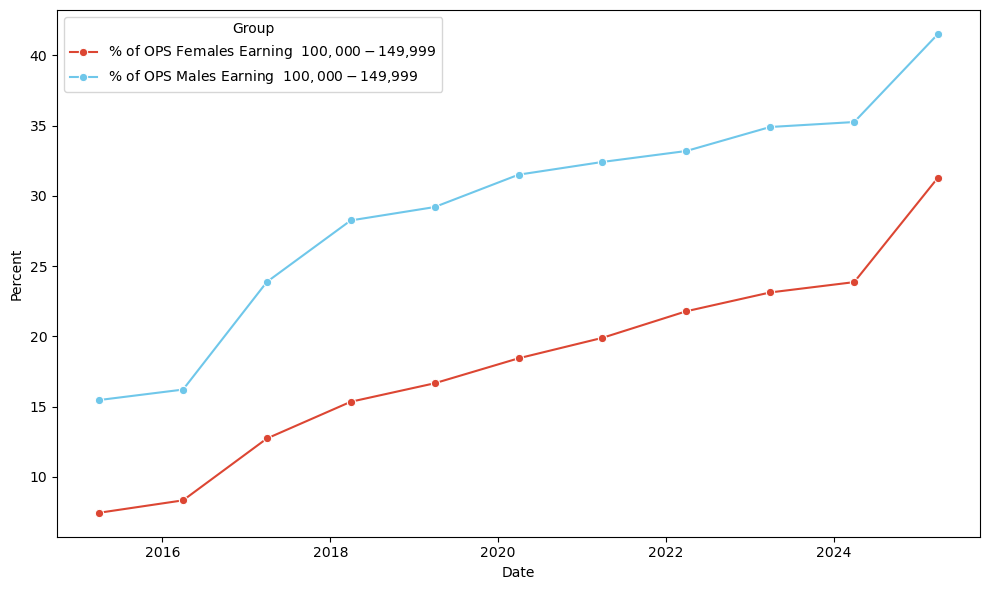

In [34]:
# plotting the data using seaborn line plot
col_f = '% of OPS Females Earning  $100,000 - $149,999'
col_m = '% of OPS Males Earning  $100,000 - $149,999'
col_af = 'Female Average Annual Salary'
col_am = 'Male Average Annual Salary'

df_plot = data_opswf[['Date', col_f, col_m]].copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])

df_long = df_plot.melt(id_vars='Date', value_vars=[col_f, col_m],
					   var_name='Group', value_name='Percent')
# change colors of lines to UofT stuff!
plt.figure(figsize=(10,6))
sns.lineplot(data=df_long, x='Date', y='Percent', hue='Group', marker='o',
             palette={'% of OPS Females Earning  $100,000 - $149,999': '#DC4633',
                       '% of OPS Males Earning  $100,000 - $149,999': '#6FC7EA'})
plt.xlabel('Date')
plt.ylabel('Percent')
plt.tight_layout()

In [35]:
# trying something else in plotly, with UofT colors, as always
graph1 = go.Figure()

graph1.add_trace(go.Scatter(x=df_plot['Date'], y=df_plot[col_f],   
                         mode='lines+markers', name=col_f,
                         line=dict(color='#DC4633', width=2)))      
graph1.add_trace(go.Scatter(x=df_plot['Date'], y=df_plot[col_m],   
                         mode='lines+markers', name=col_m,
                         line=dict(color='#6FC7EA', width=2)))
graph1.update_layout(title='Percentage of OPS Females and Males Earning $100,000 - $149,999 Over Time',
                   xaxis_title='Date',
                   yaxis_title='Percent',
                   width=800, height=500)
graph1.show()

In [36]:
# same but for these two metrics instead:
# col_af = 'Female Average Annual Salary'
# col_am = 'Male Average Annual Salary'
graph2 = go.Figure()
graph2.add_trace(go.Scatter(x=data_opswf['Date'], y=data_opswf[col_af],   
                         mode='lines+markers', name=col_af,
                         line=dict(color='#DC4633', width=2)))
graph2.add_trace(go.Scatter(x=data_opswf['Date'], y=data_opswf[col_am],   
                         mode='lines+markers', name=col_am,
                         line=dict(color='#6FC7EA', width=2)))
graph2.update_layout(title='Average Annual Salary of OPS Females and Males Over Time',
                   xaxis_title='Date',
                   yaxis_title='Average Annual Salary',
                   width=800, height=500)
# make sure y axis starts with 0k for better comparison
graph2.update_yaxes(tickprefix="$", ticksuffix="k", tick0=0, dtick=10000)


graph2.show()

In [37]:
# list column names again so that I don't have to scroll, full list as a list
list(data_opswf.columns)

['Date',
 'FTE Allocation',
 ' FTE Actuals',
 'Variance',
 'Student FTEs',
 'Intern FTEs',
 'Seasonal FTEs',
 'Pending LTIP and Salary Continuance FTEs',
 'Total Staff Strength FTEs (basis for remaining columns) ',
 'Regular FTEs',
 'Non-Regular FTEs',
 'OPSEU FTEs',
 'AMAPCEO FTEs',
 'OPPA FTEs',
 'ALOC/OCAA FTEs',
 'AOPDPS FTEs',
 'PEGO FTEs',
 'PSAT FTEs',
 'Total OPS Unionized FTEs',
 'MCP FTEs',
 'SMG/ITX FTEs',
 'Excluded FTEs',
 'OPPCOA FTEs',
 'OTHER Non-Unionized FTEs',
 'Total OPS Non-Unionized FTEs',
 'FTEs in Central Region',
 'FTEs in West Region',
 'FTEs in East Region',
 'FTEs in North Region',
 'Total Female FTEs',
 'Total Male FTEs',
 'Total Manager FTEs',
 'Female Manager FTEs',
 'Male Manager FTEs',
 'Average Age (Regular)',
 'Average Age (Non-regular)',
 'Average Age (All)',
 'Average Tenure Regular (Years)',
 'Average Tenure Non-Regular (Years)',
 'Average Tenure All (Years)',
 'Average Sick Credit Days Taken Last Complete Calendar Year',
 'Average Staff with <6 Si

In [38]:
# since the dataset conveniently already has male vs female delta columns, we can plot those too

col_delta = 'OPS Compensation by Gender: (Male - Female) / Male Salary)'
graph3 = go.Figure()
# now just a simple line plot
graph3.add_trace(go.Scatter(x=data_opswf['Date'], y=data_opswf[col_delta],   
                         mode='lines+markers', name=col_delta,
                         line=dict(color='#6D247A', width=2)))  # kinda indigo but UofT!
# make sure y axis starts with 0% and ends with maximum value (not 100%)
graph3.update_layout(title='OPS Compensation by Gender Delta Over Time (Male - Female in %)',
                   xaxis_title='Date',
                   yaxis_title='Compensation Delta',
                   yaxis=dict(range=[0, data_opswf[col_delta].max() * 1.1]),
                   width=800, height=500)
# plot starts at 0% for better comparison, unlike the above plots where we just want to see the delta
# trend continues towards more equality, thankfully

In [ ]:
# save to embed/link files for html (I love PlotLy). No error handling, it's too late, I may add it later
graph1.write_html("Data/ops_comp_gender_delta_2015-2025.html")
graph2.write_html("Data/ops_workforce_demographics.html")
graph3.write_html("Data/ops_comp_gender_delta.html")
# I deleted the files later as they take up 10+ MB but you can run the cell to save these files